In [1]:
from pathlib import Path
import hashlib
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# CONFIGURATION

SEED = 42

TEST_FRACTION = 0.20
VALIDATION_FRACTION_OF_TRAIN_POOL = 0.15

# Dataset location
PROJECT_ROOT = Path.cwd()

ARCHIVE_PATH = PROJECT_ROOT / "archive.zip"

DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "brain_tumor_mri"
)

# Output folders
OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs_efficientnetb3"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

EDA_DIR = (
    OUTPUT_DIR
    / "eda_visualizations"
)

EDA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# CLASS CONFIGURATION

CLASS_NAMES = [
    "glioma_tumor",
    "meningioma_tumor",
    "no_tumor",
    "pituitary_tumor",
]

DISPLAY_NAMES = {
    "glioma_tumor": "Glioma Tumor",
    "meningioma_tumor": "Meningioma Tumor",
    "no_tumor": "No Tumor",
    "pituitary_tumor": "Pituitary Tumor",
}

CLASS_TO_INDEX = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    i: name
    for name, i in CLASS_TO_INDEX.items()
}

# RANDOM SEEDS

random.seed(SEED)
np.random.seed(SEED)

print("Project root:", PROJECT_ROOT)
print("Archive path:", ARCHIVE_PATH)
print("Dataset directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)
print("EDA directory:", EDA_DIR)

Project root: C:\Users\ransi\Documents\AA  SLIIT\Y2S1\IT2011 AIML\My First AI Project\EfficientNetB3_Project
Archive path: C:\Users\ransi\Documents\AA  SLIIT\Y2S1\IT2011 AIML\My First AI Project\EfficientNetB3_Project\archive.zip
Dataset directory: C:\Users\ransi\Documents\AA  SLIIT\Y2S1\IT2011 AIML\My First AI Project\EfficientNetB3_Project\data\brain_tumor_mri
Output directory: C:\Users\ransi\Documents\AA  SLIIT\Y2S1\IT2011 AIML\My First AI Project\EfficientNetB3_Project\outputs_efficientnetb3
EDA directory: C:\Users\ransi\Documents\AA  SLIIT\Y2S1\IT2011 AIML\My First AI Project\EfficientNetB3_Project\outputs_efficientnetb3\eda_visualizations


In [2]:
#Building Dataframe

def build_image_dataframe(data_dir: Path) -> pd.DataFrame:
    rows = []

    for original_split in ["Training", "Testing"]:
        split_dir = data_dir / original_split
        if not split_dir.exists():
            raise FileNotFoundError(f"Missing directory: {split_dir}")

        for label in CLASS_NAMES:
            class_dir = split_dir / label
            if not class_dir.exists():
                raise FileNotFoundError(f"Missing class directory: {class_dir}")

            for path in sorted(class_dir.glob("*")):
                if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
                    rows.append({
                        "path": str(path.resolve()),
                        "filename": path.name,
                        "label": label,
                        "original_split": original_split,
                    })

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No image files were found.")

    df["label_index"] = df["label"].map(CLASS_TO_INDEX).astype(int)
    return df


df = build_image_dataframe(DATA_DIR)
print("Total images:", len(df))
display(df.head())

Total images: 3264


,path,filename,label,original_split,label_index
0,C:\Users\ransi\Documents\AA SLIIT\Y2S1\IT2011...,gg (1).jpg,glioma_tumor,Training,0
1,C:\Users\ransi\Documents\AA SLIIT\Y2S1\IT2011...,gg (10).jpg,glioma_tumor,Training,0
2,C:\Users\ransi\Documents\AA SLIIT\Y2S1\IT2011...,gg (100).jpg,glioma_tumor,Training,0
3,C:\Users\ransi\Documents\AA SLIIT\Y2S1\IT2011...,gg (101).jpg,glioma_tumor,Training,0
4,C:\Users\ransi\Documents\AA SLIIT\Y2S1\IT2011...,gg (102).jpg,glioma_tumor,Training,0


In [3]:
original_counts = (
    df.groupby(["original_split", "label"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=CLASS_NAMES)
)

total_counts = df["label"].value_counts().reindex(CLASS_NAMES)

print("Original folder counts:")
display(original_counts)

print("Combined class totals:")
display(total_counts.rename("count").to_frame())

print("Grand total:", int(total_counts.sum()))

Original folder counts:


label,glioma_tumor,meningioma_tumor,no_tumor,pituitary_tumor
original_split,,,,
Testing,100,115,105,74
Training,826,822,395,827


Combined class totals:


,count
label,
glioma_tumor,926
meningioma_tumor,937
no_tumor,500
pituitary_tumor,901


Grand total: 3264


In [4]:
# EXACT DUPLICATE DETECTION USING SHA-256

def sha256_file(path_str: str, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()

    with open(path_str, "rb") as f:
        while True:
            chunk = f.read(chunk_size)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# Calculate SHA-256 only if it has not already been calculated
if "sha256" not in df.columns:
    df["sha256"] = [sha256_file(p) for p in df["path"]]

# DUPLICATES ASSIGNED TO MULTIPLE LABELS

cross_label_hashes = df.groupby("sha256")["label"].nunique()
cross_label_hashes = cross_label_hashes[cross_label_hashes > 1]

print(
    "Exact duplicate hashes assigned to multiple labels:",
    len(cross_label_hashes)
)


if len(cross_label_hashes) > 0:

    cross_label_counts = (
        df[df["sha256"].isin(cross_label_hashes.index)]
        .groupby("label")["sha256"]
        .nunique()
        .reindex(CLASS_NAMES, fill_value=0)
    )

    plt.figure(figsize=(9, 5))

    plt.bar(
        [DISPLAY_NAMES[x] for x in CLASS_NAMES],
        cross_label_counts.values
    )

    plt.xlabel("Class")
    plt.ylabel("Conflicting Duplicate Hashes")
    plt.title("Exact Duplicates Assigned to Multiple Labels")

    plt.xticks(rotation=20)
    plt.tight_layout()

    plt.savefig(
        EDA_DIR / "eda_04_cross_label_duplicates.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


#ORIGINAL SAFETY CHECK

if len(cross_label_hashes) > 0:

    bad_hashes = set(cross_label_hashes.index)

    display(
        df[df["sha256"].isin(bad_hashes)]
        .sort_values("sha256")[
            ["path", "label", "original_split", "sha256"]
        ]
    )

    raise RuntimeError(
        "Conflicting labels found for identical images."
    )

Exact duplicate hashes assigned to multiple labels: 0


Number of exact-duplicate groups: 166
Extra duplicate files beyond one copy per group: 237


,duplicate_groups,images_in_duplicate_groups,largest_group
label,,,
glioma_tumor,22,46,3
meningioma_tumor,9,19,3
no_tumor,96,244,9
pituitary_tumor,39,94,4


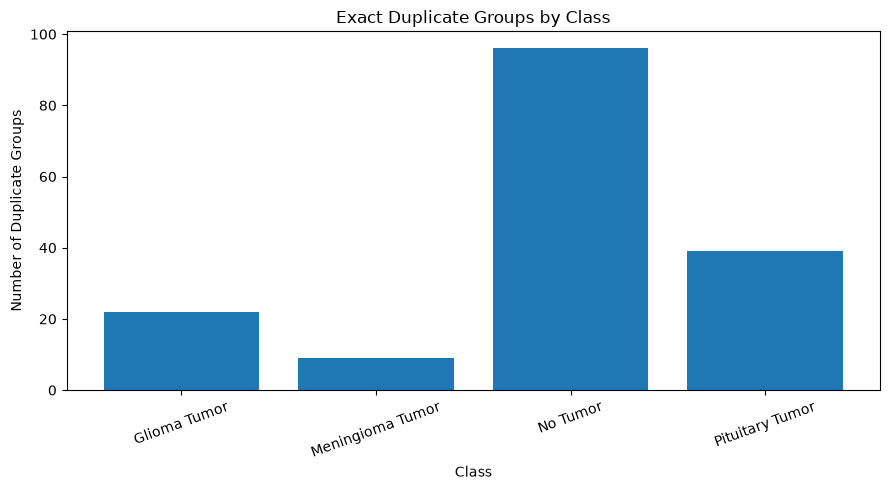

In [5]:
# EXACT DUPLICATE GROUPS WITHIN EACH CLASS

dup_groups = (
    df.groupby(["label", "sha256"])
      .size()
      .reset_index(name="copies")
)

duplicate_groups = dup_groups[
    dup_groups["copies"] > 1
]

print(
    "Number of exact-duplicate groups:",
    len(duplicate_groups)
)

print(
    "Extra duplicate files beyond one copy per group:",
    int((duplicate_groups["copies"] - 1).sum())
)


duplicate_summary = (
    duplicate_groups
    .groupby("label")
    .agg(
        duplicate_groups=("copies", "size"),
        images_in_duplicate_groups=("copies", "sum"),
        largest_group=("copies", "max")
    )
    .reindex(CLASS_NAMES)
    .fillna(0)
)

display(duplicate_summary)

# DUPLICATE GROUPS BY CLASS

plt.figure(figsize=(9, 5))

plt.bar(
    [DISPLAY_NAMES[x] for x in CLASS_NAMES],
    duplicate_summary["duplicate_groups"].values
)

plt.xlabel("Class")
plt.ylabel("Number of Duplicate Groups")
plt.title("Exact Duplicate Groups by Class")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    EDA_DIR / "eda_05_duplicate_groups_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
# DUPLICATES CROSSING ORIGINAL TRAINING / TESTING FOLDERS

original_cross_split = (
    df.groupby(["label", "sha256"])["original_split"]
      .nunique()
      .reset_index(name="num_original_splits")
)

original_cross_split = original_cross_split[
    original_cross_split["num_original_splits"] > 1
]

print(
    "Exact duplicate groups crossing ORIGINAL "
    "Training/Testing folders:",
    len(original_cross_split)
)


if len(original_cross_split):

    display(
        original_cross_split["label"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
        .rename("cross_split_duplicate_groups")
        .to_frame()
    )

Exact duplicate groups crossing ORIGINAL Training/Testing folders: 64


,cross_split_duplicate_groups
label,
glioma_tumor,0
meningioma_tumor,0
no_tumor,64
pituitary_tumor,0


In [7]:
# DUPLICATE-AWARE STRATIFIED SPLITTING

def largest_remainder_targets(
    class_counts: pd.Series,
    fraction: float
) -> pd.Series:

    # Integer allocation preserving:
    # round(total * fraction)

    exact = class_counts.astype(float) * fraction

    base = np.floor(exact).astype(int)

    target_total = int(
        round(class_counts.sum() * fraction)
    )

    remaining = target_total - int(base.sum())

    fractions = (
        exact - base
    ).sort_values(ascending=False)

    result = base.copy()

    for label in fractions.index[:remaining]:
        result.loc[label] += 1

    return result.astype(int)


def choose_groups_exactly(
    group_sizes: pd.Series,
    target: int,
    seed: int
):

    # Each exact-duplicate hash is treated
    # as one indivisible group.

    rng = np.random.default_rng(seed)

    ids = group_sizes.index.to_numpy(copy=True)

    rng.shuffle(ids)

    dp = {0: ()}

    for group_id in ids:

        size = int(
            group_sizes.loc[group_id]
        )

        for current_sum, chosen in list(dp.items()):

            new_sum = current_sum + size

            if new_sum > target or new_sum in dp:
                continue

            dp[new_sum] = (
                chosen + (group_id,)
            )

            if new_sum == target:
                return set(dp[new_sum])

    raise RuntimeError(
        f"Could not create an exact grouped split "
        f"for target={target}. "
        "Try another seed or inspect unusually "
        "large duplicate groups."
    )


def make_duplicate_aware_stratified_split(
    data: pd.DataFrame,
    test_fraction: float = 0.20,
    seed: int = 42,
):

    class_counts = (
        data["label"]
        .value_counts()
        .reindex(CLASS_NAMES)
    )

    test_targets = (
        largest_remainder_targets(
            class_counts,
            test_fraction
        )
    )

    test_indices = []

    for class_number, label in enumerate(CLASS_NAMES):

        class_df = data[
            data["label"] == label
        ]

        group_sizes = (
            class_df
            .groupby("sha256")
            .size()
            .sort_index()
        )

        chosen_test_hashes = (
            choose_groups_exactly(
                group_sizes=group_sizes,
                target=int(
                    test_targets.loc[label]
                ),
                seed=seed + class_number,
            )
        )

        class_test_indices = (
            class_df[
                class_df["sha256"]
                .isin(chosen_test_hashes)
            ]
            .index
            .tolist()
        )

        if len(class_test_indices) != int(
            test_targets.loc[label]
        ):

            raise AssertionError(
                f"{label}: expected "
                f"{test_targets.loc[label]} "
                f"test files, got "
                f"{len(class_test_indices)}"
            )

        test_indices.extend(
            class_test_indices
        )

    test_df = data.loc[
        test_indices
    ].copy()

    train_df = data.drop(
        index=test_indices
    ).copy()

    train_df = (
        train_df
        .sample(
            frac=1,
            random_state=seed
        )
        .reset_index(drop=True)
    )

    test_df = (
        test_df
        .sample(
            frac=1,
            random_state=seed
        )
        .reset_index(drop=True)
    )

    return (
        train_df,
        test_df,
        test_targets
    )

In [8]:
# FINAL 80/20 TRAIN-TEST SPLIT

train_pool_df, test_df, test_targets = (
    make_duplicate_aware_stratified_split(
        df,
        test_fraction=TEST_FRACTION,
        seed=SEED,
    )
)


print("Train pool:", len(train_pool_df))
print("Test:", len(test_df))

print(
    "Train %:",
    round(
        100 * len(train_pool_df) / len(df),
        4
    )
)

print(
    "Test %:",
    round(
        100 * len(test_df) / len(df),
        4
    )
)


# SPLIT TABLE

split_table = pd.DataFrame({

    "Total":
        df["label"]
        .value_counts()
        .reindex(CLASS_NAMES),

    "Train":
        train_pool_df["label"]
        .value_counts()
        .reindex(CLASS_NAMES),

    "Test":
        test_df["label"]
        .value_counts()
        .reindex(CLASS_NAMES),
})


split_table["Train %"] = (
    100
    * split_table["Train"]
    / split_table["Total"]
).round(2)


split_table["Test %"] = (
    100
    * split_table["Test"]
    / split_table["Total"]
).round(2)


display(
    split_table.rename(
        index=DISPLAY_NAMES
    )
)

Train pool: 2611
Test: 653
Train %: 79.9939
Test %: 20.0061


,Total,Train,Test,Train %,Test %
label,,,,,
Glioma Tumor,926,741,185,80.02,19.98
Meningioma Tumor,937,749,188,79.94,20.06
No Tumor,500,400,100,80.00,20.00
Pituitary Tumor,901,721,180,80.02,19.98


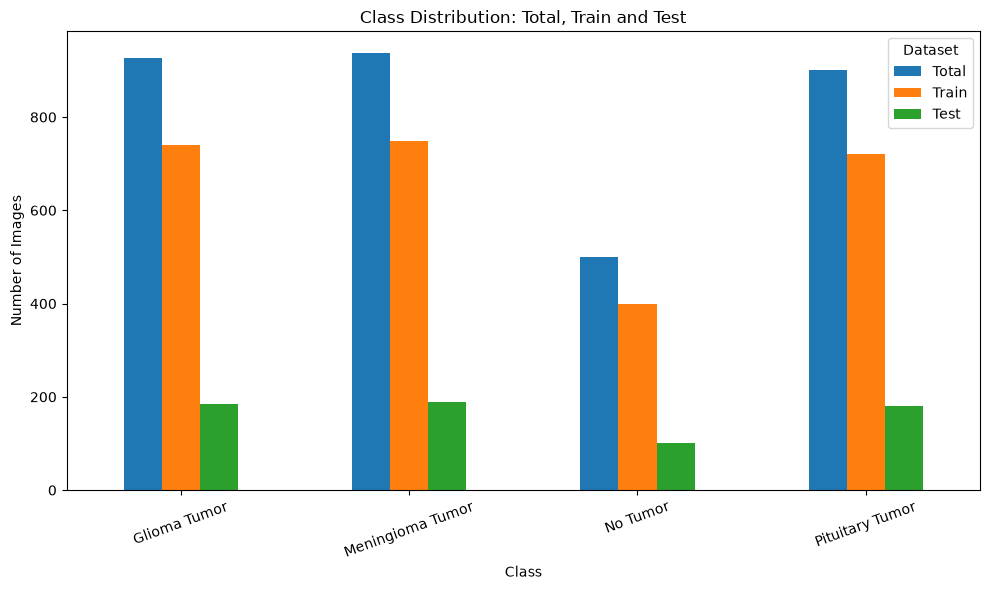

In [9]:
# EDA 6 — CLASS DISTRIBUTION: TOTAL / TRAIN / TEST

plot_data = split_table[
    ["Total", "Train", "Test"]
].copy()

plot_data.index = [
    DISPLAY_NAMES[x]
    for x in plot_data.index
]

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.set_title(
    "Class Distribution: Total, Train and Test"
)

plt.xticks(rotation=20)
plt.legend(title="Dataset")
plt.tight_layout()

plt.savefig(
    EDA_DIR / "eda_06_class_distribution_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

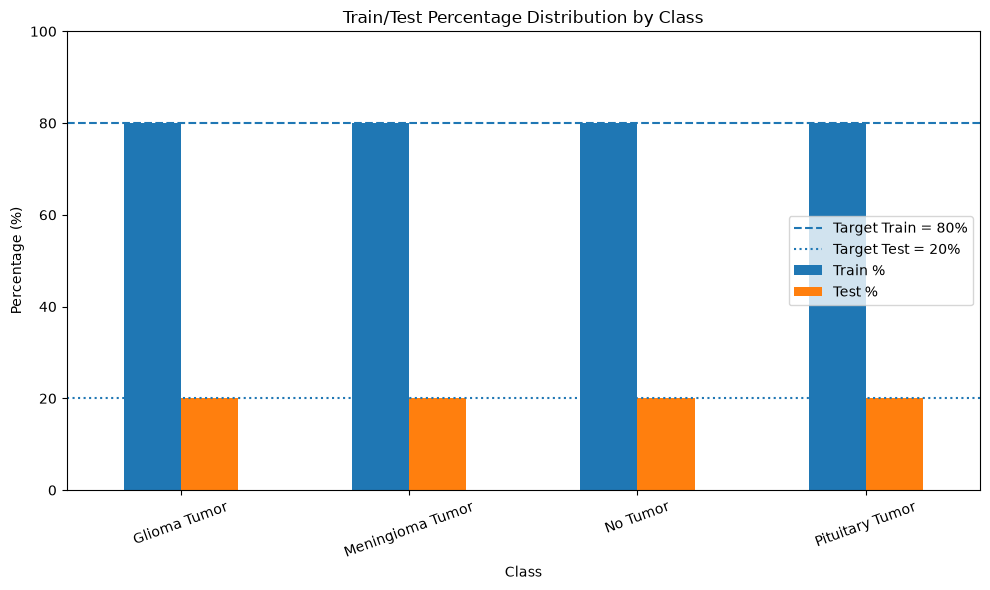

In [10]:
# EDA 7 — TRAIN / TEST PERCENTAGE DISTRIBUTION

percentage_data = split_table[
    ["Train %", "Test %"]
].copy()

percentage_data.index = [
    DISPLAY_NAMES[x]
    for x in percentage_data.index
]

ax = percentage_data.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_xlabel("Class")
ax.set_ylabel("Percentage (%)")

ax.set_title(
    "Train/Test Percentage Distribution by Class"
)

ax.axhline(
    y=80,
    linestyle="--",
    linewidth=1.5,
    label="Target Train = 80%"
)

ax.axhline(
    y=20,
    linestyle=":",
    linewidth=1.5,
    label="Target Test = 20%"
)

plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()

plt.savefig(
    EDA_DIR / "eda_07_train_test_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# FINAL TRAIN / TEST HASH LEAKAGE CHECK

train_hashes = set(
    train_pool_df["sha256"]
)

test_hashes = set(
    test_df["sha256"]
)

hash_leakage = (
    train_hashes
    .intersection(test_hashes)
)

print(
    "Exact duplicate hash leakage "
    "between FINAL train/test:",
    len(hash_leakage)
)


assert len(hash_leakage) == 0

assert (
    len(train_pool_df)
    + len(test_df)
    == len(df)
)

assert set(
    train_pool_df["path"]
).isdisjoint(
    set(test_df["path"])
)

Exact duplicate hash leakage between FINAL train/test: 0


In [12]:
# INTERNAL TRAIN / VALIDATION SPLIT

fit_train_df, val_df, _ = (
    make_duplicate_aware_stratified_split(
        train_pool_df,
        test_fraction=VALIDATION_FRACTION_OF_TRAIN_POOL,
        seed=SEED + 100,
    )
)


print("Full dataset:", len(df))
print(
    "80% train pool:",
    len(train_pool_df)
)

print(
    "  Actual fit subset:",
    len(fit_train_df)
)

print(
    "  Internal validation subset:",
    len(val_df)
)

print(
    "Final untouched 20% test:",
    len(test_df)
)


# VERIFY NO HASH LEAKAGE

fit_hashes = set(
    fit_train_df["sha256"]
)

val_hashes = set(
    val_df["sha256"]
)

test_hashes = set(
    test_df["sha256"]
)


assert not (
    fit_hashes & val_hashes
)

assert not (
    fit_hashes & test_hashes
)

assert not (
    val_hashes & test_hashes
)


# FINAL DATASET DISTRIBUTION

final_split_table = pd.DataFrame({

    "Fit train":
        fit_train_df["label"]
        .value_counts()
        .reindex(CLASS_NAMES),

    "Validation":
        val_df["label"]
        .value_counts()
        .reindex(CLASS_NAMES),

    "Final test":
        test_df["label"]
        .value_counts()
        .reindex(CLASS_NAMES),
})


display(
    final_split_table.rename(
        index=DISPLAY_NAMES
    )
)

Full dataset: 3264
80% train pool: 2611
  Actual fit subset: 2219
  Internal validation subset: 392
Final untouched 20% test: 653


,Fit train,Validation,Final test
label,,,
Glioma Tumor,630,111,185
Meningioma Tumor,636,113,188
No Tumor,340,60,100
Pituitary Tumor,613,108,180


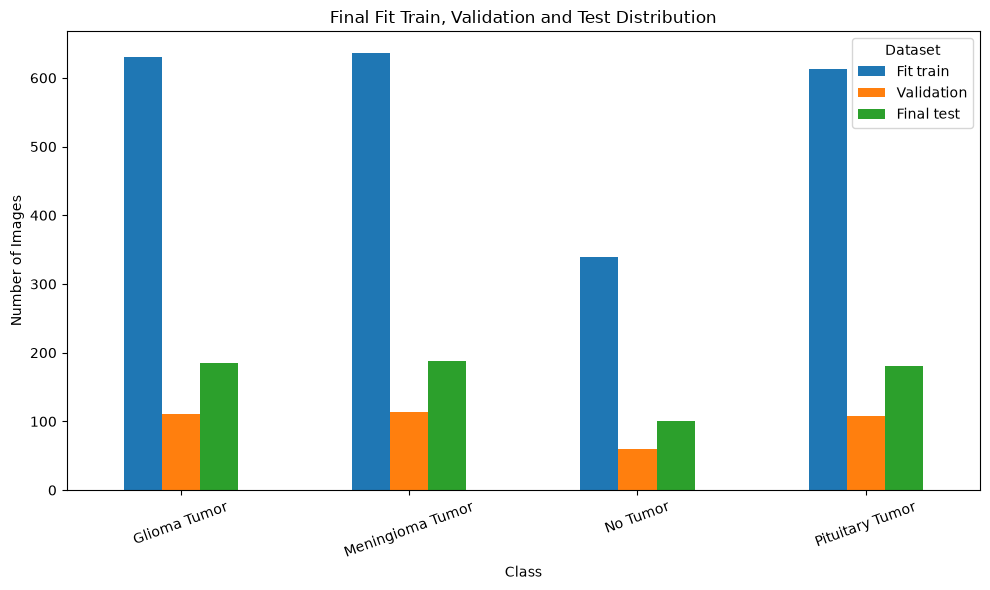

In [13]:
# EDA 9 — FINAL FIT / VALIDATION / TEST DISTRIBUTION

plot_final = final_split_table.copy()

plot_final.index = [
    DISPLAY_NAMES[x]
    for x in plot_final.index
]

ax = plot_final.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")

ax.set_title(
    "Final Fit Train, Validation and Test Distribution"
)

plt.xticks(rotation=20)
plt.legend(title="Dataset")

plt.tight_layout()

plt.savefig(
    EDA_DIR / "eda_09_final_dataset_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
train_pool_df.to_csv(OUTPUT_DIR / "train_80_percent.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_20_percent.csv", index=False)
split_table.to_csv(OUTPUT_DIR / "train_test_split_summary.csv")

print("Saved split CSV files to:", OUTPUT_DIR)

Saved split CSV files to: C:\Users\ransi\Documents\AA  SLIIT\Y2S1\IT2011 AIML\My First AI Project\EfficientNetB3_Project\outputs_efficientnetb3
